In [35]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from src import corpus,keymap,optimization

from tqdm import tqdm
import numpy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
char_freqs,bigram_matrix,chars=corpus.get_matrix_from_json("ressources/fre_en.json")
print(len(chars))
ergo_chords=keymap.generate_ergonomic_chords(3)
print(len(ergo_chords))

POP_SIZE =200  # Population size for genetic algorithm
GENS = 200  # Number of generations
MUTATION_RATE = 1  # Probability of mutation
MAX_MUTATION=10
IND_SIZE=len(ergo_chords)
layout_cost=lambda layout: (float(optimization.layout_cost(layout,char_freqs,bigram_matrix,ergo_chords)),)
mutate= lambda child: (keymap.mutate(child,MUTATION_RATE,MAX_MUTATION),)
crossover= lambda p1,p2:(keymap.crossover(p1, p2),keymap.crossover(p2, p1))


36
92


In [74]:
import random

from deap import base
from deap import creator
from deap import tools

from deap import algorithms

# creator.create("FitnessMin", base.Fitness, weights=(1.0,))
# creator.create("Individual", list, fitness=creator.FitnessMin)

creator.create("Fitness", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.Fitness)

toolbox = base.Toolbox()
# toolbox.register("attr_int", random.random)
# toolbox.register("individual", random.sample,list(range(IND_SIZE)), IND_SIZE)


# toolbox = base.Toolbox()
toolbox.register("indices", random.sample, range(IND_SIZE), IND_SIZE)
toolbox.register("individual", tools.initIterate, creator.Individual,
                 toolbox.indices)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", layout_cost)
toolbox.register("mate", crossover)
toolbox.register("mutate", mutate)
toolbox.register("select", tools.selNSGA2)

d:\temp\python\Ten_key_taipo_like\.pixi\envs\default\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Fitness' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
d:\temp\python\Ten_key_taipo_like\.pixi\envs\default\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [75]:
random.seed(64)
NGEN = GENS
MU = POP_SIZE
LAMBDA = 200
CXPB = 0.5
MUTPB = 0.5

pop = toolbox.population(n=MU)
hof = tools.ParetoFront()
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", numpy.mean, axis=0)
stats.register("std", numpy.std, axis=0)
stats.register("min", numpy.min, axis=0)
stats.register("max", numpy.max, axis=0)

pop, logbook=algorithms.eaMuPlusLambda(pop, toolbox, MU, LAMBDA, CXPB, MUTPB, NGEN, stats,
                            halloffame=hof)

# pop, stats, hof

gen	nevals	avg          	std      	min         	max          
0  	200   	[13.90580202]	[3.08284]	[6.47223167]	[22.58851416]
1  	200   	[11.46643187]	[1.72054619]	[5.46431815]	[13.69661599]
2  	200   	[10.21814225]	[1.43705622]	[5.46431815]	[11.65578778]
3  	200   	[8.99659609] 	[1.35386829]	[4.39500895]	[10.58780951]
4  	200   	[7.94776736] 	[1.22698822]	[3.48332836]	[9.53997349] 
5  	200   	[7.00952727] 	[1.04299681]	[3.45322254]	[8.47968126] 
6  	200   	[6.23286198] 	[0.99670926]	[3.43569921]	[7.48942179] 
7  	200   	[5.51926971] 	[0.87668103]	[3.43116929]	[6.51029853] 
8  	200   	[4.82731906] 	[0.74959367]	[2.39472889]	[5.58375671] 
9  	200   	[4.26493031] 	[0.65313385]	[2.39472889]	[5.39174742] 
10 	200   	[3.81419392] 	[0.66499143]	[1.51968293]	[4.47189176] 
11 	200   	[3.46163892] 	[0.64700864]	[1.37891675]	[4.39726631] 
12 	200   	[3.02500527] 	[0.63645346]	[0.39056744]	[3.50352625] 
13 	200   	[2.68844409] 	[0.70439777]	[0.38995622]	[3.41285284] 
14 	200   	[2.13591949] 	[0.557

In [76]:
top10 = tools.selBest(pop, k=10)
gen, minimum = logbook.select("gen", "min")

Text(0.5, 1.0, '[0.10436249]')

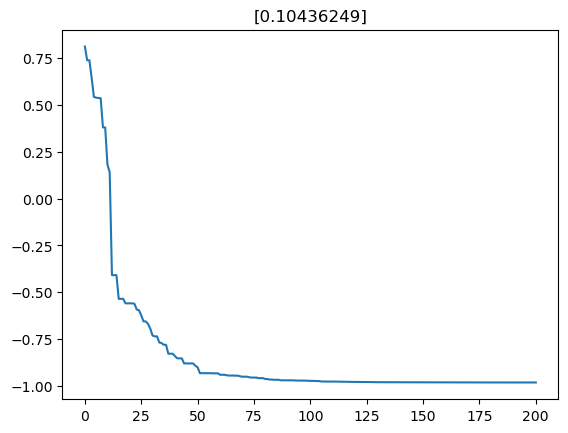

In [80]:
plt.plot(gen,np.log10(minimum))
plt.title(minimum[-1])

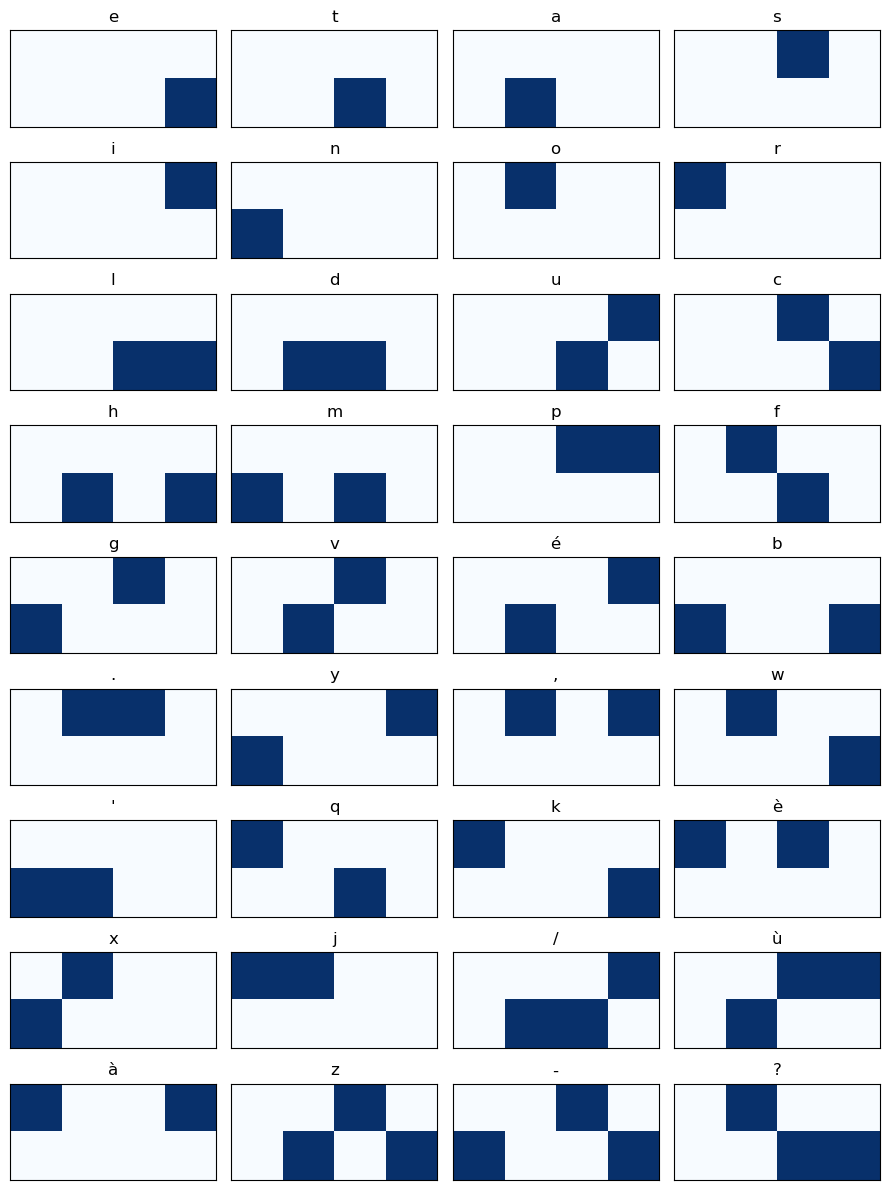

In [81]:
keymap.plot_layout_nicer(top10[0],ergo_chords,chars)

In [85]:
keymap.save_keymaps(top10[0],ergo_chords,chars)

In [82]:
list_chord=keymap.get_chords(top10[0],ergo_chords,chars)
display(keymap.get_list_combo_per_letters(list_chord,chars))

{'e': 'e',
 't': 't',
 'a': 'a',
 's': 's',
 'i': 'i',
 'n': 'n',
 'o': 'o',
 'r': 'r',
 'l': 'te',
 'd': 'at',
 'u': 'it',
 'c': 'se',
 'h': 'ae',
 'm': 'nt',
 'p': 'si',
 'f': 'ot',
 'g': 'sn',
 'v': 'sa',
 'é': 'ia',
 'b': 'ne',
 '.': 'os',
 'y': 'in',
 ',': 'oi',
 'w': 'oe',
 'QUOT': 'na',
 'q': 'rt',
 'k': 're',
 'è': 'rs',
 'x': 'on',
 'j': 'ro',
 '/': 'iat',
 'ù': 'sia',
 'à': 'ri',
 'z': 'sae',
 '-': 'sne',
 '?': 'ote'}